## Notebook loading and viewing DNA files

This notebook is used for **loading and viewing DNA files** in different formats (e.g., FASTA, FASTQ, GTF, GFF).  

## Contents

- **Import of libraries** for working with sequence data  
- **Loading DNA sequences** from files  
- **Display and initial exploration** of the loaded data  

## Purpose

The notebook is meant as a **toy example** to get familiar with **Biopython sequence objects** and to **take a first look at plasmid maps**.  
It provides a simple environment to explore and learn a few basic functions.  

## Usage

1. Place the desired DNA files into the working directory.  
2. Run the cells step by step.  
3. Inspect the loaded sequences and annotations.  


In [1]:
# Core
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Iterable, Dict, Any

# Project 
from assembly_designer.plasmidio import (
    load_dna_file,
    remove_near_duplicate_features,
)

# BioPython & viz
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from Bio.SeqFeature import SeqFeature, FeatureLocation, CompoundLocation
import matplotlib.pyplot as plt
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator


c:\Users\stoltmann\AppData\Local\mambaforge\envs\adesigner\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


### 01 Helper

In [2]:
# Load ExpressionUnitTranslator

class ExpressionUnitTranslator(BiopythonTranslator):
    """Custom translator with per-type color and label filtering + label-keyword fallback."""

    def __init__(
        self,
        features_to_show: Optional[Iterable[str]] = None,
        color_map: Optional[Dict[str, str]] = None,
        label_keyword_colors: Optional[Dict[str, str]] = None,
        enable_label_keywords: bool = True,
        **kwargs: Any,
    ) -> None:
        """
        Parameters
        ----------
        features_to_show
            Iterable of feature.type values to label (case-insensitive).
            If None or empty, labels are shown for all features.
        color_map
            Mapping from feature.type (case-insensitive) to color (matplotlib-compatible).
        label_keyword_colors
            Fallback mapping from *keywords found in labels* (case-insensitive) to colors.
            Checked only if no type color was found.
        enable_label_keywords
            Toggle the label-keyword fallback coloring.
        kwargs
            Passed to BiopythonTranslator (e.g., label_fields).
        """
        super().__init__(**kwargs)
        self.features_to_show = {t.casefold() for t in (features_to_show or [])}

        # Primary: color by feature.type
        self.color_map: Dict[str, str] = {
            k.casefold(): v for k, v in (color_map or {
                "rep_origin": "yellow",
                "cds": "#ffd383",          # light orange
                "regulatory": "red",
                "misc_recomb": "darkblue",
                "misc_feature": "#d1e9f1", # light blue
                "backbone": "darkblue",
                "promoter": "#118ab2",
                "rbs": "#073b4c",
                "terminator": "#ef476f",
                "gene": "#06d6a0",
            }).items()
        }

        # Secondary: color by label keywords (preserves insertion order)
        self.label_keyword_colors: Dict[str, str] = {
            k.casefold(): v for k, v in (label_keyword_colors or {
                "promoter": "#118ab2",
                "rbs": "#073b4c",
                "terminator": "#ef476f",
                "ori": "#8e7dbe",
                "origin": "#8e7dbe",
                "cds": "#ffd383",
                "gene": "#06d6a0",
            }).items()
        }

        self.enable_label_keywords: bool = enable_label_keywords

    # ---- internals ---------------------------------------------------------

    def _ftype(self, feature) -> str:
        """Return normalized (casefolded) feature.type, with a default."""
        return (getattr(feature, "type", "misc_feature") or "misc_feature").casefold()

    def _label_text(self, feature) -> str:
        """Return a unified, lowercase label string from common qualifiers."""
        q = getattr(feature, "qualifiers", {}) or {}
        # Prefer label -> gene -> product -> note
        cand: List[str] = []
        for key in ("label", "gene", "product", "note", "locus_tag"):
            val = q.get(key)
            if isinstance(val, list) and val:
                cand.append(str(val[0]))
            elif isinstance(val, str):
                cand.append(val)
        text = " ".join(cand).strip()
        return text.casefold()

    # ---- coloring & labeling -----------------------------------------------

    def compute_feature_color(self, feature):
        """Color by feature.type; fallback to label keyword matches; then gray."""
        # 1) type-based color
        color = self.color_map.get(self._ftype(feature))
        if color:
            return color

        # 2) label-keyword fallback
        if self.enable_label_keywords and self.label_keyword_colors:
            text = self._label_text(feature)
            if text:
                for kw, kw_color in self.label_keyword_colors.items():
                    if kw in text:
                        return kw_color

        # 3) final fallback
        return "gray"

    def compute_feature_label(self, feature):
        """Show labels only for selected types (if configured)."""
        if not self.features_to_show or self._ftype(feature) in self.features_to_show:
            return super().compute_feature_label(feature)
        return None
    
# helper 

def _label_text(f):
    q = f.qualifiers or {}
    lab = q.get("label") or q.get("gene") or q.get("product") or ""
    return (lab[0] if isinstance(lab, list) else lab) or ""


### 02 Parameter 

In [3]:
# Pick a test plasmid file (.dna or .gb/.gbk)
PLASMID_FILE = Path("../02 insilico Plasmid Construction/01 GoldenGateCloning/reports/Assembly/J23100_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb")  # <-- adjust path
# features to show in map
features_to_show = ["promoter", "RBS", "CDS", "terminator", "misc_feature","5'UTR","3'UTR"]
# color overrides (optional)
translator = ExpressionUnitTranslator(
    features_to_show=features_to_show,
    color_map={  # override or extend type colors
        "promoter": "#1f77b4",
        "rbs": "#2ca02c",
        "3'UTR": "#2ca02c",
        "5'UTR": "#2ca02c",
        "cds": "#ff7f0e",
        "terminator": "#d62728",
        "rep_origin": "#9467bd",
        "misc_feature": "#cccccc",
    },
    label_keyword_colors={  # fallback when type is generic (e.g., misc_feature)
        "promoter": "#1f77b4",
        "rbs": "#2ca02c",
        "terminator": "#d62728",
        "ori": "#9467bd",
        "origin": "#9467bd",
        "cds": "#ff7f0e",
        "gene": "#17becf",
    },
    enable_label_keywords=True,
    # label_fields=["label", "gene", "product", "note", "locus_tag"],  # optional
)


### 02 Plasmid Viewer

In [20]:
# load file
rec = load_dna_file(PLASMID_FILE)
print(f"Loaded {PLASMID_FILE.name}: {len(rec.seq)} bp, features={len(rec.features)}")

Loaded J23100_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb: 2814 bp, features=11


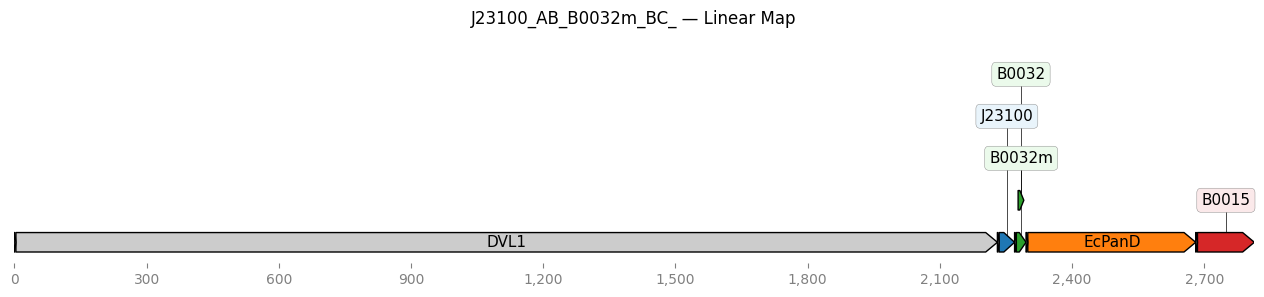

Saved: c:\Repo\assembly_designer_test\examples\06 View DNA files\J23100_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF_map.png and c:\Repo\assembly_designer_test\examples\06 View DNA files\J23100_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF_map.svg


In [19]:

# --- Linear plot ---
gr = translator.translate_record(rec)  # 'rec' is a BioPython SeqRecord
ax, _ = gr.plot(figure_width=16)
ax.set_title(f"{rec.id} — Linear Map")
plt.show()

ax, _ = gr.plot(figure_width=12)   # returns matplotlib Axes
fig = ax.figure

# --- Save into the *notebook folder* ---
out_dir = Path.cwd()  # this is the current notebook's directory
out_base = out_dir / f"{PLASMID_FILE.stem}_map"

# Save both PNG and SVG (high quality + editable)
fig.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{out_base}.svg", bbox_inches="tight")

plt.close(fig)  # free memory
print(f"Saved: {out_base}.png and {out_base}.svg")


### 04 Change feature type 

In [7]:
# Print feature index, type, [start..end), strand and label
for i, f in enumerate(rec.features, 1):
    # pick a human-friendly label
    q = f.qualifiers or {}
    lab = q.get("label") or q.get("gene") or q.get("product") or f.type
    label = lab[0] if isinstance(lab, list) else lab

    start = int(f.location.start)  # 0-based, inclusive
    end   = int(f.location.end)    # 0-based, exclusive (Biopython convention)
    strand = {1: "+", -1: "-", 0: "0", None: "?"}.get(f.location.strand, "?")

    print(f"{i:02d}. {f.type:12} [{start:>5}..{end:<5}) s={strand}  {label}")

01. homology     [    0..4    ) s=+  CGCT
02. misc_feature [    4..2231 ) s=+  DVL1
03. homology     [ 2231..2235 ) s=+  GGAG
04. promoter     [ 2235..2270 ) s=+  J23100
05. homology     [ 2270..2274 ) s=+  TACT
06. 5'UTR        [ 2278..2291 ) s=+  B0032
07. 5'UTR        [ 2274..2296 ) s=+  B0032m
08. homology     [ 2296..2300 ) s=+  AATG
09. CDS          [ 2300..2681 ) s=+  EcPanD
10. homology     [ 2681..2685 ) s=+  AGGT
11. misc_feature [ 2685..2814 ) s=+  B0015


In [8]:
# Force feature at position 11 to be a terminator
i = 10  # example index (0-based)
f = rec.features[i]
f.type = "terminator"
f.qualifiers = f.qualifiers or {}
f.qualifiers.setdefault("label", ["terminator"])


['B0015']

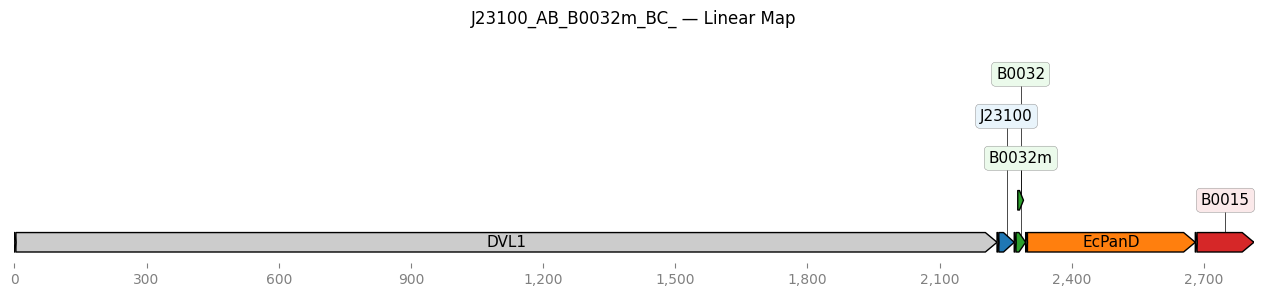

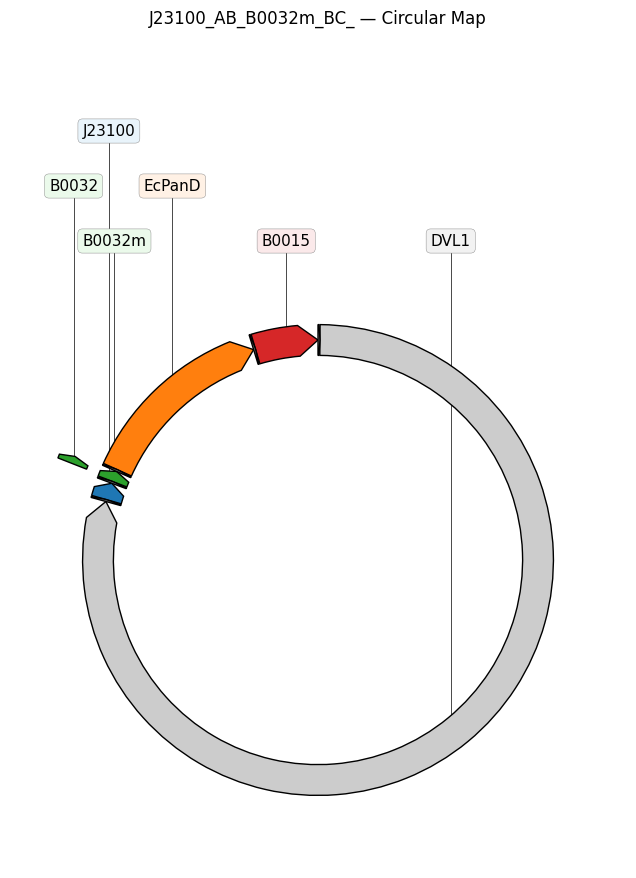

In [9]:
# plot again 

# --- Linear plot ---
gr = translator.translate_record(rec)  # 'rec' is a BioPython SeqRecord
ax, _ = gr.plot(figure_width=16)
ax.set_title(f"{rec.id} — Linear Map")
plt.show()

# --- Circular plot ---
cgr = CircularGraphicRecord(
    sequence_length=gr.sequence_length,
    features=gr.features
)
ax, _ = cgr.plot(figure_width=8)
ax.set_title(f"{rec.id} — Circular Map")
plt.show()

### 05 Add a feature

- Biopython uses 0-based and end-exclusive: [start..end).

- For circular plasmids that run across the origin, use CompoundLocation (example 3).

- Qualifier values should be lists (e.g., “label”: [“gfp”]) so that tools such as dna_features_viewer/BioPython work correctly.

- Your ExpressionUnitTranslator colors the new types directly according to color_map.

In [10]:
#from Bio.SeqFeature import SeqFeature, FeatureLocation, CompoundLocation

L = len(rec.seq)  # plasmid length

# 1) Simple feature (e.g., promoter) on the + strand
start, end, strand = 1200, 1280, 1  # [start..end) 0-based; end is exclusive
rec.features.append(
    SeqFeature(
        location=FeatureLocation(start, end, strand=strand),
        type="promoter",
        qualifiers={"label": ["J23100"], "note": ["strong promoter"]}
    )
)

# 2) Terminator on the - strand
start, end, strand = 2100, 2180, -1
rec.features.append(
    SeqFeature(
        location=FeatureLocation(start, end, strand=strand),
        type="terminator",
        qualifiers={"label": ["rrnB_T1"], "note": ["E. coli terminator"]}
    )
)

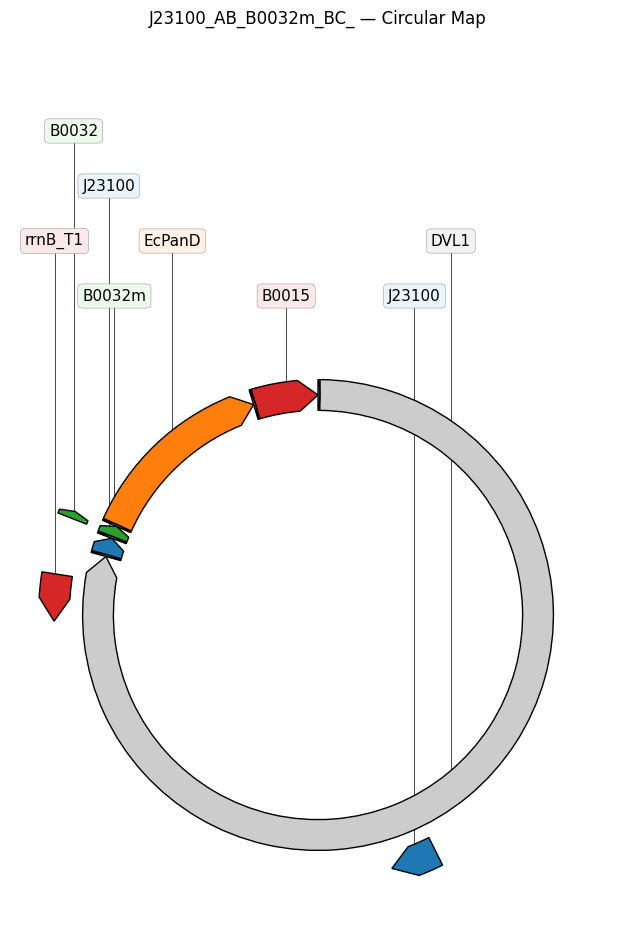

In [11]:
# --- Circular plot ---
gr = translator.translate_record(rec)
cgr = CircularGraphicRecord(
    sequence_length=gr.sequence_length,
    features=gr.features
)
ax, _ = cgr.plot(figure_width=8)
ax.set_title(f"{rec.id} — Circular Map")
plt.show()

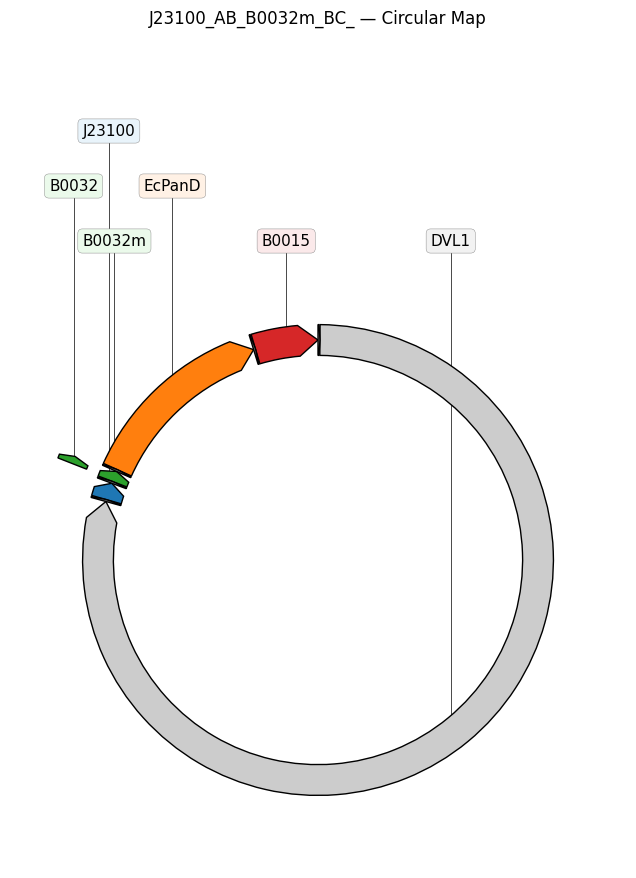

In [12]:
# Delete features at given indices (delete from the end to keep indices valid)
# indices_to_delete = [7, -1]  # example
# for i in sorted(indices_to_delete, reverse=True):
#     del rec.features[i]

to_delete = []
for i, f in enumerate(rec.features):
    if f.type == "promoter" and int(f.location.start) == 1200 and int(f.location.end) == 1280 and (f.location.strand or 0) == 1:
        if _label_text(f).casefold() == "j23100":
            to_delete.append(i)
    if f.type == "terminator" and int(f.location.start) == 2100 and int(f.location.end) == 2180 and (f.location.strand or 0) == -1:
        if _label_text(f).casefold() == "rrnb_t1":
            to_delete.append(i)

for i in sorted(to_delete, reverse=True):
    del rec.features[i]

# --- Circular plot ---
gr = translator.translate_record(rec)
cgr = CircularGraphicRecord(
    sequence_length=gr.sequence_length,
    features=gr.features
)
ax, _ = cgr.plot(figure_width=8)
ax.set_title(f"{rec.id} — Circular Map")
plt.show()

In [13]:
# When adding:
promoter_feat = SeqFeature(FeatureLocation(1200, 1280, strand=1), type="promoter",
                           qualifiers={"label": ["J23100"]})
rec.features.append(promoter_feat)

terminator_feat = SeqFeature(FeatureLocation(2100, 2180, strand=-1), type="terminator",
                             qualifiers={"label": ["rrnB_T1"]})
rec.features.append(terminator_feat)

# Later: remove by object reference (no indices needed)
for feat in (promoter_feat, terminator_feat):
    if feat in rec.features:
        rec.features.remove(feat)


In [14]:
# (Optional) quick check
for i, f in enumerate(rec.features[-5:], 1):
    s = f.location
    if isinstance(s, CompoundLocation):
        parts = ", ".join(f"[{int(p.start)}..{int(p.end)})" for p in s.parts)
        loc = f"join({parts})"
    else:
        loc = f"[{int(s.start)}..{int(s.end)})"
    label = (f.qualifiers.get("label") or [f.type])[0]
    print(f"{i}. {f.type:12} {loc}  {label}")

1. 5'UTR        [2274..2296)  B0032m
2. homology     [2296..2300)  AATG
3. CDS          [2300..2681)  EcPanD
4. homology     [2681..2685)  AGGT
5. terminator   [2685..2814)  B0015


In [15]:
# # 3) Feature that WRAPS around the origin (e.g., spans end -> start)
# wrap_start, wrap_end = L - 50, 30  # e.g., 50 bp before end to 30 bp after origin
# rec.features.append(
#     SeqFeature(
#         location=CompoundLocation([
#             FeatureLocation(wrap_start, L, strand=1),
#             FeatureLocation(0, wrap_end, strand=1),
#         ]),
#         type="rep_origin",
#         qualifiers={"label": ["ori"], "note": ["wrap-around feature across origin"]}
#     )
# )

# # 4) Joined feature with multiple parts (e.g., misc_recomb with two arms)
# part1 = FeatureLocation(3000, 3150, strand=1)
# part2 = FeatureLocation(3400, 3550, strand=1)
# rec.features.append(
#     SeqFeature(
#         location=CompoundLocation([part1, part2]),
#         type="misc_recomb",
#         qualifiers={"label": ["loxP-joined"], "note": ["two-part feature"]}
#     )
# )



### 06 Insert DNA at a given index (linear)

- BioPython uses 0-based, end-exclusive coordinates [start..end).

- Seq is immutable → build new sequences over and over again, and then rec.seq = new_seq.

- There is no "circular mode" in Seq for circular plasmids; You implement the wrap-around using slicing/modulo, as shown.

- The feature updates above are minimal (for demos). In real-world pipelines, you would clip overlapping features or convert them into a CompoundLocation.

In [ ]:

insert_pos = 1500                 # 0-based, insertion before this index
fragment   = Seq("GGGAAATTTCCC")  # your insert
print(len(fragment))

# make a new sequence by concatenation (Seq is immutable, so create a new one)
new_seq = rec.seq[:insert_pos] + fragment + rec.seq[insert_pos:]
rec.seq = new_seq

print("New length:", len(rec.seq))


12
New length: 2826


In [ ]:
# Delete a region [start..end) (linear)
start, end = 1500, 1513  # end is exclusive
rec.seq = rec.seq[:start] + rec.seq[end:]
print("New length:", len(rec.seq))

New length: 2813


In [ ]:
# Insert reverse-complement (if you need opposite orientation)

# insert_pos = 1500
# fragment   = Seq("ACGTTGCA")
# rc_fragment = fragment.reverse_complement()

# rec.seq = rec.seq[:insert_pos] + rc_fragment + rec.seq[insert_pos:]